## Instance Segmentation

In [1]:
import tensorflow as tf
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
!rm -rf "./train.zip"
!rm -rf "./validation.zip"
!rm -rf "../data"

!wget "https://s3-us-west-1.amazonaws.com/udacity-robotics/Deep+Learning+Data/Lab/train.zip"
!wget "https://s3-us-west-1.amazonaws.com/udacity-robotics/Deep+Learning+Data/Lab/validation.zip"

!mkdir -p "../data/train"
#!mkdir -p "../data/validation"

!unzip "train.zip" -d "../data"
!unzip "validation.zip" -d "../data"

!mv "../data/train_combined/images/" "../data/train/"
!mv "../data/train_combined/masks/" "../data/train/"
!rm -rf "../data/train_combined/"

Streaming output truncated to the last 5000 lines.
  inflating: ../data/train_combined/masks/4_run2_mask_00072.png  
  inflating: ../data/train_combined/masks/4_run2_mask_00073.png  
  inflating: ../data/train_combined/masks/4_run2_mask_00076.png  
  inflating: ../data/train_combined/masks/4_run2_mask_00077.png  
  inflating: ../data/train_combined/masks/4_run2_mask_00078.png  
  inflating: ../data/train_combined/masks/4_run2_mask_00079.png  
  inflating: ../data/train_combined/masks/4_run2_mask_00080.png  
  inflating: ../data/train_combined/masks/4_run2_mask_00081.png  
  inflating: ../data/train_combined/masks/4_run2_mask_00082.png  
  inflating: ../data/train_combined/masks/4_run2_mask_00083.png  
  inflating: ../data/train_combined/masks/4_run2_mask_00084.png  
  inflating: ../data/train_combined/masks/4_run2_mask_00085.png  
  inflating: ../data/train_combined/masks/4_run2_mask_00086.png  
  inflating: ../data/train_combined/masks/4_run2_mask_00089.png  
  inflating: ../data/trai

## Data Loading

In [2]:
import glob
from tqdm import tqdm
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split

In [3]:
train_dir = "../data/train"
valid_dir = "../data/validation"

In [4]:
train_images_paths, train_masks_paths = shuffle(sorted(glob.glob(train_dir+"/images/*.jpeg")), sorted(glob.glob(train_dir+"/masks/*.png")), random_state=42)
#train_masks_paths = glob.glob(train_dir+"/masks/*.png")

valid_images_paths, valid_masks_paths = shuffle(glob.glob(valid_dir+"/images/*.jpeg"), glob.glob(valid_dir+"/masks/*.png"), random_state=42)

assert len(train_images_paths) == len(train_masks_paths)
assert len(valid_images_paths) == len(valid_masks_paths)

In [5]:
print(f"Total train images is {len(train_images_paths)}")
print(f"Total validation images is {len(valid_images_paths)}")

Total train images is 4131
Total validation images is 1184


In [6]:
def load_images(path_list):
    loaded_images = []
    for path in path_list:
        loaded_images.append(cv2.imread(path))
    return np.array(loaded_images)

train_images = load_images(train_images_paths)
train_masks = load_images(train_masks_paths)
valid_images = load_images(valid_images_paths)
valid_masks = load_images(valid_masks_paths)

In [7]:
print(f"Train images shape is {train_images.shape}")
print(f"Train masks shape is {train_masks.shape}")
print(f"Valid images shape is {valid_images.shape}")
print(f"Valid masks shape is {valid_masks.shape}")

Train images shape is (4131, 256, 256, 3)
Train masks shape is (4131, 256, 256, 3)
Valid images shape is (1184, 256, 256, 3)
Valid masks shape is (1184, 256, 256, 3)


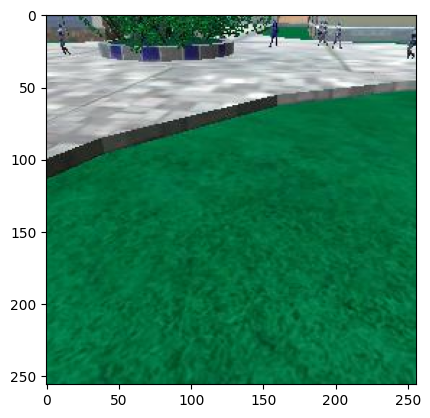

In [8]:
# Visual representation of data
plt.imshow(train_images[110])

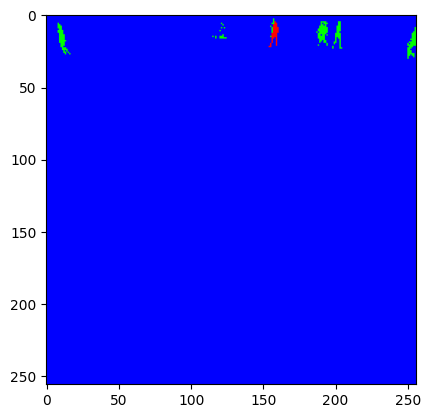

In [9]:
plt.imshow(train_masks[110])

In [10]:
#print(train_masks[1][10:11])
# From here I can see how the segmentation is done on this dataset in that:
# red is the person of interest [255, 0, 0]
# blue is the uninterested region [0, 0, 255]
# green is the people class [0, 255, 0]

In [11]:
def preprocess(images):
    return images/255.0

In [12]:
train_masks = np.array(train_masks/255.0, dtype=np.int8)#preprocess(train_masks)
valid_images = np.array(valid_masks/255.0, dtype=np.int8)#preprocess(valid_masks)

In [13]:
#train_images = train_images/255.0

In [14]:
#valid_images = valid_images/255.0

In [15]:
batch_size = 8

train_ds = (
    tf.data.Dataset.from_tensor_slices((train_images, train_masks))
    .shuffle(1000)
    .batch(batch_size)
    .prefetch(tf.data.AUTOTUNE)
#    .repeat()
)
train_images=0

valid_ds = (
    tf.data.Dataset.from_tensor_slices((valid_images, valid_masks))
    .batch(batch_size)
    .prefetch(tf.data.AUTOTUNE)
)
valid_images = 0

## Defining model

In [16]:
from keras.models import Model
from keras.layers import Conv2D, Rescaling, Input, UpSampling2D, Concatenate, GlobalAveragePooling2D, UpSampling2D, Reshape, BatchNormalization, Activation
from keras.applications import ResNet50, MobileNetV2
from keras.metrics import BinaryIoU

In [17]:
input_shape = (256, 256, 3)
trainable = False
def conv_block(inputs, filters, dilation_rate=1, kernel_size=3, stride=1):
    #print("work_conv")
    x = Conv2D(filters, kernel_size, (stride, stride), padding="same", use_bias=False, dilation_rate=(dilation_rate, dilation_rate))(inputs)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)
    #print("End_conv")
    return x

In [18]:
def base_model(inputs, input_shape=(256, 256, 3), trainable=False):
    base = ResNet50(
        weights="imagenet",
        include_top=False,
        input_shape=input_shape,
        input_tensor=inputs
    )
    base.trainable = trainable
    return base

In [19]:
def ASPP(input_tensor):
    shape = input_tensor.shape
    #print("Start")
    layer1 = conv_block(input_tensor, 256, 1, 1, 1)
    #print("2")
    layer2 = conv_block(input_tensor, 256, 6, 3, 1)
    #print("3")
    layer3 = conv_block(input_tensor, 256, 12, 3, 1)
    #print("4")
    layer4 = conv_block(input_tensor, 256, 18, 3, 1)
    #print("5")
    layer5 = GlobalAveragePooling2D()(input_tensor)
    layer5 = Reshape((1, 1, layer5.shape[-1]))(layer5)
    layer5 = conv_block(layer5, 256, kernel_size=1)
    layer5 = UpSampling2D(
        size=(shape[1], shape[2]), interpolation="bilinear")(layer5)
    layers_add = Concatenate()([layer1, layer2, layer3, layer4, layer5])
    output = conv_block(layers_add, 256, 1, 1, 1)
    #print("End")
    return output

In [20]:
def encoder(base):
    layers = [
        "conv2_block3_out",
        "conv4_block6_out"
    ]
    layers = [base.get_layer(name).output for name in layers]
    #model_input = base_model(input_tensor, input_shape=input_shape, trainable)
    #model_ouput = ASPP(model_input)
    #encoder_model = Model(model_input, model_output)
    model = Model(base.input, layers)
    return model

In [21]:
def decoder(base_input, ASPP_input):
    #print("Start Decoder")
    layer1 = UpSampling2D(size=(4, 4), interpolation="bilinear")(ASPP_input)
    layer_add = Concatenate()([base_input, layer1])
    layer3 = conv_block(layer_add, 256, 1, 3, 1)
    output = UpSampling2D(size=(4, 4), interpolation="bilinear")(layer3)
    #print("End Decoder")
    return output

In [22]:
def deeplabv3plus(num_classes=3):
    inputs = Input(shape=input_shape)
    rescaled=Rescaling(scale=1./255)(inputs)
    base = base_model(rescaled, input_shape=input_shape, trainable=trainable)
    encoder_output = encoder(base)
    low_level, base_output = encoder_output.output
    aspp_out = ASPP(base_output)
    #print("End encoder")

    low_level = conv_block(low_level, 48, 1, 1, 1)
    decoder_out = decoder(low_level, aspp_out)
    output = Conv2D(num_classes, 1, padding="same")(decoder_out)
    model = Model(inputs=inputs, outputs=output)
    return model

In [23]:
model = deeplabv3plus()

## Training and Testing

In [31]:
learning_rate = 1e-4
batch_size=4
epochs = 40

In [32]:
# Dice Loss and cross entropy loss
def dice_loss(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    intersection = tf.reduce_sum(y_true * y_pred, axis=[1, 2, 3])
    union = tf.reduce_sum(y_true, axis=[1, 2, 3]) + tf.reduce_sum(y_pred, axis=[1, 2, 3])
    d_loss = (2 * intersection + smooth) / (union + smooth)
    return 1.0 - tf.reduce_mean(d_loss)

cross_entropy_loss = tf.keras.losses.BinaryCrossentropy()


def total_loss(y_true, y_pred):
  return dice_loss(y_true, y_pred) + cross_entropy_loss(y_true, y_pred)

In [33]:
# meen IoU
def meanIoU():
    mI
    return mIoU

In [34]:
import tensorflow as tf

class MeanIoUCustom(tf.keras.metrics.Metric):
    def __init__(self, num_classes, ignore_class=None, name="mIoU", **kwargs):
        super().__init__(name=name, **kwargs)
        self.num_classes = num_classes
        self.ignore_class = ignore_class

        self.total_cm = self.add_weight(
            name="total_confusion_matrix",
            shape=(num_classes, num_classes),
            initializer="zeros",
            dtype=tf.float32
        )

    def update_state(self, y_true, y_pred, sample_weight=None):
        """
        y_true: (B, H, W)
        y_pred: (B, H, W, C) logits
        """
        y_pred = tf.argmax(y_pred, axis=-1)
        y_true = tf.cast(y_true, tf.int32)
        y_pred = tf.cast(y_pred, tf.int32)

        # Flatten
        y_true = tf.reshape(y_true, [-1])
        y_pred = tf.reshape(y_pred, [-1])

        # Ignore label mask
        if self.ignore_class is not None:
            mask = tf.not_equal(y_true, self.ignore_class)
            y_true = tf.boolean_mask(y_true, mask)
            y_pred = tf.boolean_mask(y_pred, mask)

        cm = tf.math.confusion_matrix(
            y_true,
            y_pred,
            num_classes=self.num_classes,
            dtype=tf.float32
        )

        self.total_cm.assign_add(cm)

    def result(self):
        sum_over_row = tf.reduce_sum(self.total_cm, axis=0)
        sum_over_col = tf.reduce_sum(self.total_cm, axis=1)
        true_positives = tf.linalg.diag_part(self.total_cm)

        denominator = sum_over_row + sum_over_col - true_positives
        iou = true_positives / (denominator + 1e-7)

        return tf.reduce_mean(iou)

    def reset_states(self):
        self.total_cm.assign(tf.zeros_like(self.total_cm))

In [35]:
miou = MeanIoUCustom(num_classes=3, ignore_class=255)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
    loss=total_loss,
    #metrics=["accuracy"]
    #metrics=[miou]
    metrics = [BinaryIoU(target_class_ids=[0, 1], threshold=0.3)]
)

In [ ]:
#model.fit(
#    train_images, train_masks,
#    batch_size=batch_size,
#    epochs=epochs,
#)
model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=epochs,
)

Epoch 1/40
517/517 ━━━━━━━━━━━━━━━━━━━━ 147s 249ms/step - binary_io_u_2: 0.4536 - loss: 4.2667 - val_binary_io_u_2: 0.4658 - val_loss: 951.2075
Epoch 2/40
517/517 ━━━━━━━━━━━━━━━━━━━━ 117s 225ms/step - binary_io_u_2: 0.4344 - loss: 4.8102 - val_binary_io_u_2: 0.3932 - val_loss: 433.6395
Epoch 3/40
517/517 ━━━━━━━━━━━━━━━━━━━━ 120s 232ms/step - binary_io_u_2: 0.4519 - loss: 4.6940 - val_binary_io_u_2: 0.4375 - val_loss: 392.6912
Epoch 4/40
517/517 ━━━━━━━━━━━━━━━━━━━━ 119s 230ms/step - binary_io_u_2: 0.4563 - loss: 4.4839 - val_binary_io_u_2: 0.4406 - val_loss: 319.0495
Epoch 5/40
517/517 ━━━━━━━━━━━━━━━━━━━━ 119s 230ms/step - binary_io_u_2: 0.4803 - loss: 4.2726 - val_binary_io_u_2: 0.4458 - val_loss: 267.5845
Epoch 6/40
517/517 ━━━━━━━━━━━━━━━━━━━━ 119s 230ms/step - binary_io_u_2: 0.5050 - loss: 4.0530 - val_binary_io_u_2: 0.4495 - val_loss: 200.3089
Epoch 7/40
517/517 ━━━━━━━━━━━━━━━━━━━━ 119s 231ms/step - binary_io_u_2: 0.5291 - loss: 3.8509 - val_binary_io_u_2: 0.4538 - val_loss: 1

In [36]:
model.save("deeplabv3.keras")

In [37]:
valid_images = load_images(valid_images_paths)

In [38]:
index = 10
test_im = valid_images[index]

In [39]:
test_im = tf.reshape(test_im, [1, test_im.shape[0], test_im.shape[-2], test_im.shape[-1]])
test_im.shape


TensorShape([1, 256, 256, 3])

In [40]:
output = model.predict([test_im])

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=('Tensor(shape=(1, 256, 256, 3))',)
  warnings.warn(msg)


1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step


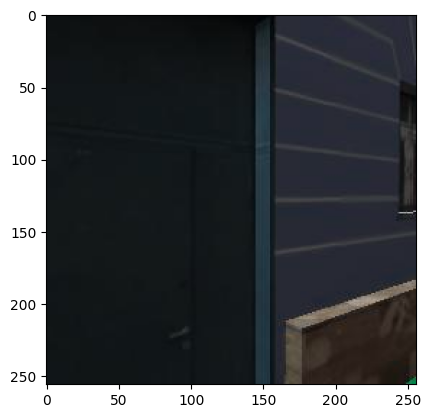

In [41]:
plt.imshow(test_im[0])

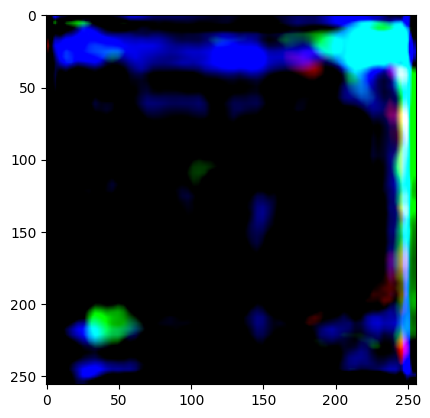

In [42]:
plt.imshow(output[0])

In [43]:
print(output[0])

[[[ 0.06336173 -2.7614357  -0.84313166]
  [ 0.06336173 -2.7614357  -0.84313166]
  [-0.17415936 -2.4500053  -0.5955037 ]
  ...
  [-1.7431705  -2.1437504  -0.69180155]
  [-1.8789091  -2.1459424  -1.0594779 ]
  [-1.8789091  -2.1459424  -1.0594779 ]]

 [[ 0.06336173 -2.7614357  -0.84313166]
  [ 0.06336173 -2.7614357  -0.84313166]
  [-0.17415936 -2.4500053  -0.5955037 ]
  ...
  [-1.7431705  -2.1437504  -0.69180155]
  [-1.8789091  -2.1459424  -1.0594779 ]
  [-1.8789091  -2.1459424  -1.0594779 ]]

 [[ 0.023677   -2.5782118  -0.971553  ]
  [ 0.023677   -2.5782118  -0.971553  ]
  [-0.2201873  -2.2742877  -0.7383731 ]
  ...
  [-1.5459044  -1.9503963  -0.70137066]
  [-1.6527257  -1.9543848  -1.0675293 ]
  [-1.6527257  -1.9543848  -1.0675293 ]]

 ...

 [[-2.1223545  -1.5539345  -2.4091208 ]
  [-2.1223545  -1.5539345  -2.4091208 ]
  [-2.2030654  -1.6311859  -2.3208232 ]
  ...
  [-2.8288722  -2.0757263  -0.87612796]
  [-2.6398263  -1.9882787  -1.0200963 ]
  [-2.6398263  -1.9882787  -1.0200963 ]]

 [

In [ ]:
def deeplabv3plus(num_classes=3):
    inputs = Input(shape=input_shape)
    rescaled=Rescaling(scale=1./255)(inputs)
    base = base_model(rescaled, input_shape=input_shape, trainable=False)
    encoder_output = encoder(base)
    low_level, base_output = encoder_output.output
    aspp_out = ASPP(base_output)
    #print("End encoder")

    low_level = conv_block(low_level, 48, 1, 1, 1)
    decoder_out = decoder(low_level, aspp_out)
    output = Conv2D(num_classes, 1, padding="same")(decoder_out)
    model = Model(inputs=inputs, outputs=output)
    return model

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
    loss=total_loss,
    #metrics=["accuracy"]
    #metrics=[miou]
    metrics = [BinaryIoU(target_class_ids=[0, 1], threshold=0.3)]
)

In [ ]:
model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=epochs,
)